In [1]:
import os
os.environ["https_proxy"] = "http://127.0.0.1:37890"
os.environ["http_proxy"] = "http://127.0.0.1:37890"
os.environ["all_proxy"] = "socks5://127.0.0.1:37890"
import matplotlib.pyplot as plt
from diffusers import DiTPipeline, DPMSolverMultistepScheduler
import torch
import numpy as np
import utils


2025-08-02 12:31:19.282325: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-02 12:31:19.299537: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1754137879.319853 3647157 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1754137879.325495 3647157 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1754137879.341263 3647157 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
pipe = DiTPipeline.from_pretrained("facebook/DiT-XL-2-256", torch_dtype=torch.float16,local_files_only=True)
pipe = pipe.to("cuda:2")
pipe.set_progress_bar_config(disable=True)
import copy
old = dict(copy.deepcopy(pipe.scheduler.config))

Loading pipeline components...:   0%|          | 0/3 [00:00<?, ?it/s]

An error occurred while trying to fetch /home/jinc/.cache/huggingface/hub/models--facebook--DiT-XL-2-256/snapshots/eab87f77abd5aef071a632f08807fbaab0b704d0/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /home/jinc/.cache/huggingface/hub/models--facebook--DiT-XL-2-256/snapshots/eab87f77abd5aef071a632f08807fbaab0b704d0/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


An error occurred while trying to fetch /home/jinc/.cache/huggingface/hub/models--facebook--DiT-XL-2-256/snapshots/eab87f77abd5aef071a632f08807fbaab0b704d0/transformer: Error no file named diffusion_pytorch_model.safetensors found in directory /home/jinc/.cache/huggingface/hub/models--facebook--DiT-XL-2-256/snapshots/eab87f77abd5aef071a632f08807fbaab0b704d0/transformer.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


In [3]:
class_ids = [207]
keys = [k for k, v in pipe.labels.items() if v == class_ids[0]]
print(class_ids,keys) 

[207] ['golden retriever']


In [4]:
guidance_scale = 1.5
num_inference_steps_list = [5, 6, 7, 8, 9, 25]
seed = 1

In [5]:
from diffusers import DDIMScheduler,UniPCMultistepScheduler 

images_flops = []
images_dpm = []
images_uni = []
images_ddim = []
images_aflops = []

for num_steps in num_inference_steps_list:
    # # FLoPSScheduler
    current_config = copy.deepcopy(old)
    current_config.update({
        "c_max": 1,
        "mode": 0
    })
    pipe.scheduler = utils.AFloPS_DIT.from_config(current_config)
    generator = torch.manual_seed(seed)
    output = pipe(class_labels=class_ids, num_inference_steps=num_steps,
                  generator=generator, guidance_scale=guidance_scale)
    images_flops.append(output.images[0])

    # A-FLoPSScheduler
    current_config = copy.deepcopy(old)
    current_config.update({
        "c_max": 1,
        "mode": 1
    })
    pipe.scheduler = utils.AFloPS_DIT.from_config(current_config)
    generator = torch.manual_seed(seed)
    output = pipe(class_labels=class_ids, num_inference_steps=num_steps,
                  generator=generator, guidance_scale=guidance_scale)
    images_aflops.append(output.images[0])

    # DPMSolverMultistepScheduler
    pipe.scheduler = DPMSolverMultistepScheduler.from_config(old)
    generator = torch.manual_seed(seed)
    output = pipe(class_labels=class_ids, num_inference_steps=num_steps,
                  generator=generator, guidance_scale=guidance_scale)
    images_dpm.append(output.images[0])

    # UniPCMultistepScheduler
    pipe.scheduler = UniPCMultistepScheduler.from_config(old)
    generator = torch.manual_seed(seed)
    output = pipe(class_labels=class_ids, num_inference_steps=num_steps,
                  generator=generator, guidance_scale=guidance_scale)
    images_uni.append(output.images[0])

    # DDIMScheduler
    pipe.scheduler = DDIMScheduler.from_config(old)
    generator = torch.manual_seed(seed)
    output = pipe(class_labels=class_ids, num_inference_steps=num_steps,
                  generator=generator, guidance_scale=guidance_scale)
    images_ddim.append(output.images[0])


/tmp/ipykernel_3647157/716244647.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


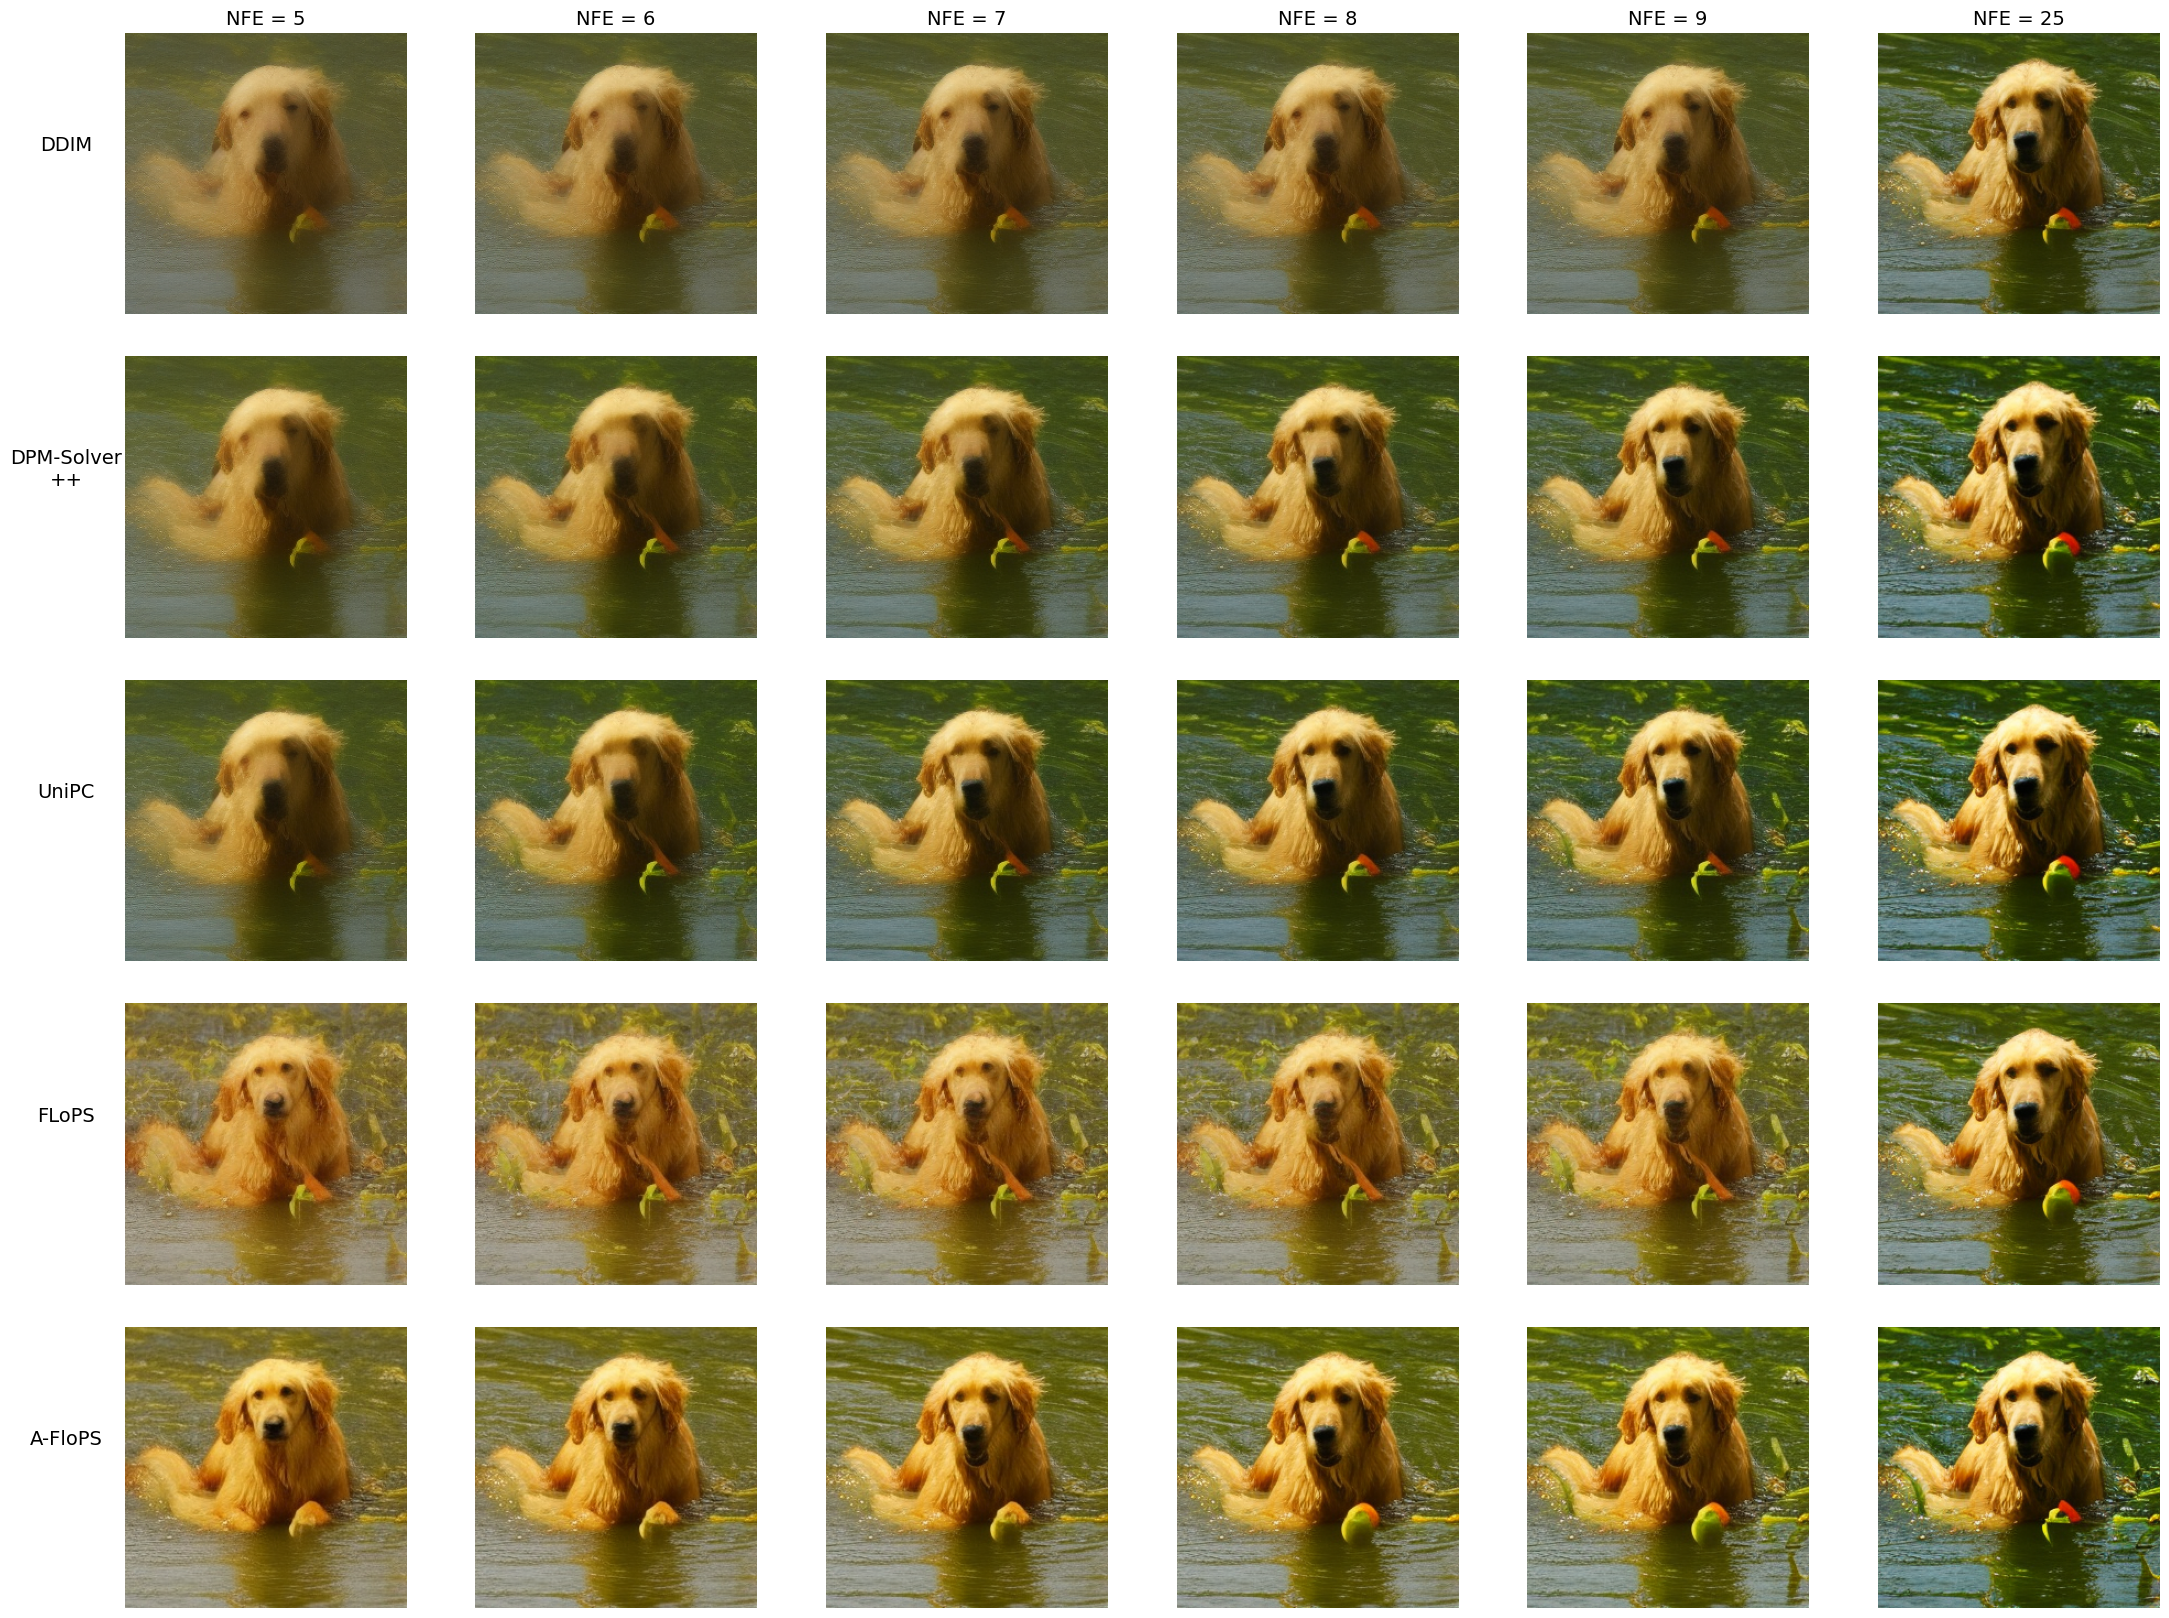

In [6]:
import matplotlib.pyplot as plt
import numpy as np


image_sets = [images_ddim, images_dpm, images_uni, images_flops, images_aflops]

methods_info = [
    {"name": "DDIM", "extra": ""},
    {"name": "DPM-Solver\n++", "extra": "++"},
    {"name": "UniPC", "extra": ""},
    {"name": "FLoPS", "extra": "(ours)"}, 
    {"name": "A-FloPS", "extra": "(ours)"} 
]

num_rows = len(methods_info)
num_cols_images = len(num_inference_steps_list)

fig, axes = plt.subplots(
    nrows=num_rows,
    ncols=num_cols_images + 1,
    figsize=(num_cols_images * 3.5 + 1.5, num_rows * 3.5),
    gridspec_kw={
        'wspace': 0.05,
        'hspace': 0.15,
        'width_ratios': [0.1] + [1] * num_cols_images
    }
)


axes = axes.reshape(num_rows, num_cols_images + 1)

for row in range(num_rows):

    label_ax = axes[row, 0]

    label_ax.set_xticks([])
    label_ax.set_yticks([])
    for spine in label_ax.spines.values():
        spine.set_visible(False)

    label_ax.text(
        0.5,
        0.6, 
        methods_info[row]["name"],
        fontsize=14,
        rotation=0, 
        verticalalignment='center',   
        horizontalalignment='center', 
        transform=label_ax.transAxes,

    )


    for col_img in range(num_cols_images):

        ax = axes[row, col_img + 1]
        ax.imshow(image_sets[row][col_img])
        

        if row == 0:
            ax.set_title(f"NFE = {num_inference_steps_list[col_img]}", fontsize=14)
        

        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)


plt.tight_layout()
plt.subplots_adjust(left=0.03, right=0.98, top=0.95, bottom=0.05)
# plt.savefig("comparison_grid.png", dpi=300, bbox_inches='tight')
# plt.savefig("comparison_grid.jpg")
plt.show()